In [125]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

TIME_LIMIT = 1000.0
LAMBDA_BASE = 30.0
MU_BASE = 1.0
SEED = 42

In [126]:
def theoretical_metrics(lmbda, mu):
    rho = lmbda / mu
    p_reject = rho / (1 + rho)
    p_busy = rho / (1 + rho)
    q = 1 - p_reject
    throughput = lmbda * q
    return {
        "rho": rho,
        "p_reject": p_reject,
        "p_busy": p_busy,
        "q": q,
        "throughput": throughput
    }

In [127]:
def simulate_mm10(lmbda, mu, time_limit=1000.0, seed=None):
    if seed is not None:
        random.seed(seed)

    current_time = 0.0
    next_arrival = random.expovariate(lmbda)
    next_departure = float("inf")

    server_busy = False
    busy_time = 0.0
    last_event_time = 0.0

    arrived = 0
    served = 0
    rejected = 0

    while True:
        next_event_time = min(next_arrival, next_departure)

        if next_event_time > time_limit:
            if server_busy:
                busy_time += time_limit - last_event_time
            break

        if server_busy:
            busy_time += next_event_time - last_event_time

        current_time = next_event_time
        last_event_time = current_time

        if next_arrival < next_departure:
            arrived += 1

            if server_busy:
                rejected += 1
            else:
                server_busy = True
                service_time = random.expovariate(mu)
                next_departure = current_time + service_time

            next_arrival = current_time + random.expovariate(lmbda)
        else:
            served += 1
            server_busy = False
            next_departure = float("inf")

    rejection_probability = rejected / arrived if arrived > 0 else 0.0
    busy_coefficient = busy_time / time_limit if time_limit > 0 else 0.0

    return {
        "lambda": lmbda,
        "mu": mu,
        "arrived": arrived,
        "served": served,
        "rejected": rejected,
        "p_reject_exp": rejection_probability,
        "busy_exp": busy_coefficient
    }

In [128]:
sim = simulate_mm10(LAMBDA_BASE, MU_BASE, TIME_LIMIT, SEED)
theory = theoretical_metrics(LAMBDA_BASE, MU_BASE)

print("Поступило:", sim["arrived"])
print("Обслужено:", sim["served"])
print("Потеряно:", sim["rejected"])
print("P отказа (эксп):", round(sim["p_reject_exp"], 6))
print("P отказа (теор):", round(theory["p_reject"], 6))
print("Загрузка (эксп):", round(sim["busy_exp"], 6))
print("Загрузка (теор):", round(theory["p_busy"], 6))

Поступило: 30127
Обслужено: 937
Потеряно: 29189
P отказа (эксп): 0.968865
P отказа (теор): 0.967742
Загрузка (эксп): 0.969384
Загрузка (теор): 0.967742


In [129]:
def run_lambda_series(mu, lambda_values, time_limit=1000.0, base_seed=42):
    results = []

    for i, lmbda in enumerate(lambda_values):
        sim = simulate_mm10(lmbda, mu, time_limit, seed=base_seed + i)
        theory = theoretical_metrics(lmbda, mu)

        results.append({
            "lambda": lmbda,
            "arrived": sim["arrived"],
            "served": sim["served"],
            "rejected": sim["rejected"],
            "p_reject_exp": sim["p_reject_exp"],
            "p_reject_theory": theory["p_reject"],
            "busy_exp": sim["busy_exp"],
            "busy_theory": theory["p_busy"]
        })

    return results

In [130]:
lambda_values = np.arange(10, 101, 10)
results = run_lambda_series(MU_BASE, lambda_values)

df = pd.DataFrame(results)

T = TIME_LIMIT

df_counts = pd.DataFrame({
    "λ": df["lambda"],
    "Поступило (эксп)": df["arrived"],
    "Поступило (теор)": df["lambda"] * T,
    "Обслужено (эксп)": df["served"],
    "Обслужено (теор)": df["lambda"] * T * (1 - df["p_reject_theory"]),
    "Потеряно (эксп)": df["rejected"],
    "Потеряно (теор)": df["lambda"] * T * df["p_reject_theory"]
})

df_probs = pd.DataFrame({
    "λ": df["lambda"],
    "P отказа (эксп)": df["p_reject_exp"].round(4),
    "P отказа (теор)": df["p_reject_theory"].round(4),
    "Загрузка (эксп)": df["busy_exp"].round(4),
    "Загрузка (теор)": df["busy_theory"].round(4)
})

df_counts, df_probs

(     λ  Поступило (эксп)  Поступило (теор)  Обслужено (эксп)  \
 0   10             10013           10000.0               933   
 1   20             19965           20000.0               960   
 2   30             29836           30000.0               930   
 3   40             40104           40000.0               957   
 4   50             50209           50000.0               914   
 5   60             59459           60000.0               937   
 6   70             69686           70000.0               955   
 7   80             80552           80000.0              1011   
 8   90             89419           90000.0              1017   
 9  100             99584          100000.0              1024   
 
    Обслужено (теор)  Потеряно (эксп)  Потеряно (теор)  
 0        909.090909             9079      9090.909091  
 1        952.380952            19004     19047.619048  
 2        967.741935            28905     29032.258065  
 3        975.609756            39146     39024.390244 

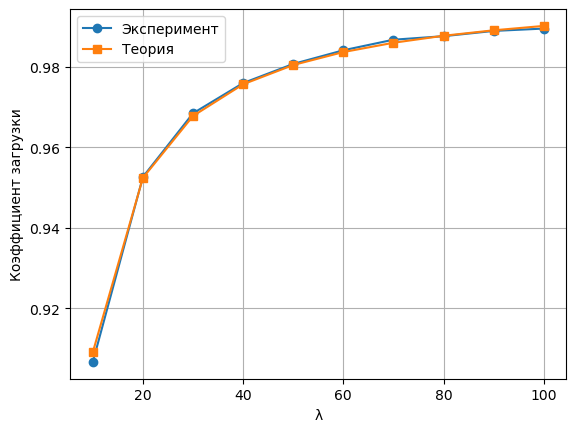

In [131]:
lambdas = [r["lambda"] for r in results]
busy_exp = [r["busy_exp"] for r in results]
busy_theory = [r["busy_theory"] for r in results]

plt.figure()
plt.plot(lambdas, busy_exp, marker='o', label="Эксперимент")
plt.plot(lambdas, busy_theory, marker='s', label="Теория")
plt.xlabel("λ")
plt.ylabel("Коэффициент загрузки")
plt.legend()
plt.grid()
plt.show()

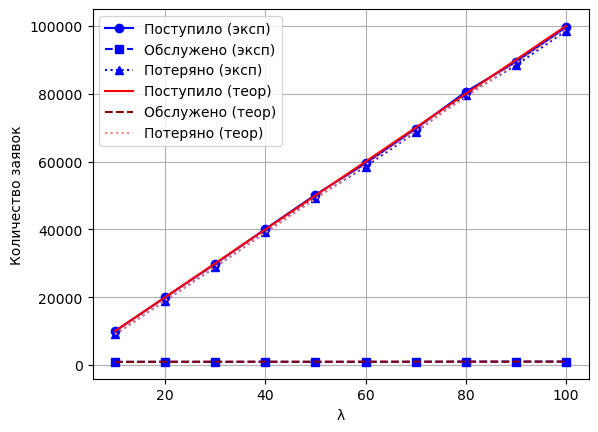

In [132]:
arrived = [r["arrived"] for r in results]
served = [r["served"] for r in results]
rejected = [r["rejected"] for r in results]

T = TIME_LIMIT

arrived_theory = [l * T for l in lambdas]
served_theory = [l * T * (1 - r["p_reject_theory"]) for l, r in zip(lambdas, results)]
rejected_theory = [l * T * r["p_reject_theory"] for l, r in zip(lambdas, results)]

plt.figure()

plt.plot(lambdas, arrived, marker='o', color='blue', label="Поступило (эксп)")
plt.plot(lambdas, served, marker='s', color='blue', linestyle='--', label="Обслужено (эксп)")
plt.plot(lambdas, rejected, marker='^', color='blue', linestyle=':', label="Потеряно (эксп)")

plt.plot(lambdas, arrived_theory, color='red', label="Поступило (теор)")
plt.plot(lambdas, served_theory, color='darkred', linestyle='--', label="Обслужено (теор)")
plt.plot(lambdas, rejected_theory, color='salmon', linestyle=':', label="Потеряно (теор)")

plt.xlabel("λ")
plt.ylabel("Количество заявок")
plt.legend()
plt.grid()
plt.show()

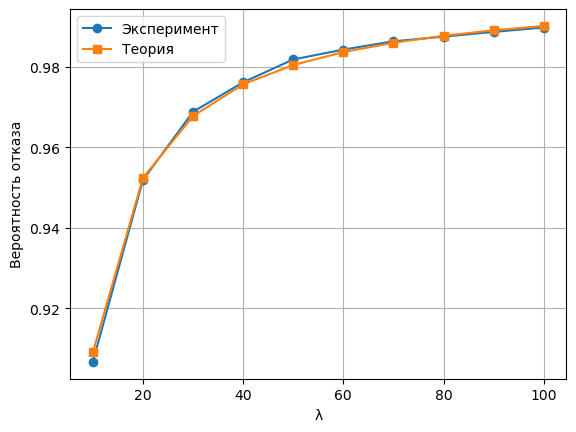

In [133]:
lambdas = [r["lambda"] for r in results]
p_exp = [r["p_reject_exp"] for r in results]
p_theory = [r["p_reject_theory"] for r in results]

plt.figure()
plt.plot(lambdas, p_exp, marker='o', label="Эксперимент")
plt.plot(lambdas, p_theory, marker='s', label="Теория")
plt.xlabel("λ")
plt.ylabel("Вероятность отказа")
plt.legend()
plt.grid()
plt.show()